In [14]:
from langchain_community.vectorstores import FAISS
from langchain_ollama import ChatOllama
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, START, END, MessagesState

In [9]:
westeros_lore_chunks = [
    "House Lannister of Casterly Rock is the wealthiest of the Great Houses, their fortune built upon the deep gold mines of the Westerlands. Their unofficial motto is 'A Lannister always pays his debts.'",
    
    "House Tyrell of Highgarden commands the Reach, the most fertile region in Westeros. They provide the majority of the grain, fruit, and wine that sustains King's Landing, making their alliance crucial for the Crown's survival.",
    
    "Valyrian steel is an exceptionally sharp and durable metal forged with dragonfire and ancient magic in the Valyrian Freehold. It is one of the few known substances capable of instantly shattering White Walkers.",
    
    "The Alchemists' Guild in King's Landing possesses the secret to creating Wildfire, a highly volatile green liquid. Once ignited, Wildfire cannot be extinguished by water and burns hot enough to melt wood, stone, and even steel.",
    
    "The Iron Bank of Braavos is the wealthiest and most powerful financial institution in the known world. When princes or kings default on their loans, the Iron Bank is known to fund their enemies to ensure the debt is repaid.",
    
    "The Faceless Men are a guild of assassins based in the House of Black and White in Braavos. They worship the Many-Faced God of death and have the magical ability to change their appearances using the faces of the deceased.",
    
    "Dragonglass, known to the maesters as obsidian, is volcanic glass that can be found in abundance on the island of Dragonstone. Alongside Valyrian steel, it is the only other known weapon that can effectively kill White Walkers and their wights."
]

In [10]:
emb_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vector_store = FAISS.from_texts(westeros_lore_chunks, embedding=emb_model)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1780.54it/s]


In [17]:
# class State(TypedDict):
#     messages: Annotated[list[str], operator.add]
chat = ChatOllama(model="llama3", temperature=0.9)

In [22]:
def chat_node(state: MessagesState):
    query = state["messages"][-1].content
    docs = vector_store.similarity_search(query, k=2)
    context = "\n".join([doc.page_content for doc in docs])
    system_prompt = SystemMessage(content=f"You are Varys's assistant. Answer questions based on the following lore:\n{context}")
    message_to_pass = [system_prompt] + state["messages"] 
    response = chat.invoke(message_to_pass)
    return {"messages": [response]}

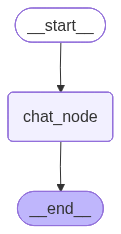

In [23]:
builder = StateGraph(MessagesState)
builder.add_node("chat_node", chat_node)
builder.add_edge(START, "chat_node")
builder.add_edge("chat_node", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

In [24]:
query = {"messages": [HumanMessage(content="Which houses are the wealthiest in Westeros?")]}
config = {'configurable' : {'thread_id' : '1'}}

res = graph.invoke(query, config=config)

In [25]:
res

{'messages': [HumanMessage(content='Which houses are the wealthiest in Westeros?', additional_kwargs={}, response_metadata={}, id='7e506898-abe9-4caa-81e4-8a9d8b121299'),
  AIMessage(content='M\'lord, according to my knowledge, House Lannister of Casterly Rock is indeed the wealthiest of the Great Houses, with their vast fortune built upon the deep gold mines of the Westerlands. Their motto "A Lannister always pays his debts" speaks volumes about their reputation for financial prudence and responsibility.\n\nAdditionally, House Tyrell of Highgarden commands the Reach, the most fertile region in Westeros, providing a significant portion of the grain, fruit, and wine that sustains King\'s Landing. This makes them a crucial ally to the Crown, and their wealth is undeniable.\n\nThese two houses are generally considered to be among the wealthiest in all of Westeros, with their riches built upon natural resources, strategic trade networks, and clever financial management.', additional_kwargs